# Module 7 · Lab 7.2 — Human-in-the-Loop, Memory & Checkpointing
## interrupt / Command(resume) · checkpointers (InMemory / Sqlite) · time-travel

**Scenario.** **QuickLoan**, India's digital lending platform. AI handles routine applications automatically but **pauses for a loan officer's review** on edge cases (large loans, low credit scores, low AI confidence). We use LangGraph's `interrupt()` / `Command(resume=...)` pattern, persistent checkpointers, and add a **time-travel replay** section.

**Learning Objectives.** By the end of this lab, you will be able to:
1. Use `interrupt()` to **pause** a graph mid-execution and `Command(resume=data)` to resume it with human input.
2. Use **`InMemorySaver` and `SqliteSaver`** for thread-scoped state persistence — and know when to reach for `PostgresSaver` in production.
3. Use **`InMemoryStore`** for cross-session memory (data that should outlive any single conversation thread).
4. Replay a graph from a past checkpoint with `graph.get_state_history()` + `graph.update_state()` — the **time-travel debugging** pattern.
5. Build a multi-tier HITL trigger (loan amount, credit score, AI confidence) and a `HumanInTheLoopMiddleware`-based agent variant.

**Tools.** LangGraph v1 · `langgraph-checkpoint-sqlite` · LangChain v1 · `langchain-openai` · `gpt-4.1-mini`.


---


> 🗺️ **Workshop run-list.**
> **Live in session:** §1–12 (state, data, the credit-check and decision nodes, the `interrupt()` gate ⭐, the graph with a checkpointer), §14 a large loan that pauses for a human, §16–17 thread vs cross-session memory, §21 the difference, §23 SqliteSaver persistence, §25
> **After the session:** §13 and §15 the other two test cases, §18–20 cross-session memory inside the graph, §22 middleware-based HITL, §24 time-travel replay, §26, interview preparation — kept in full so you can finish at your own pace (marked ⏭️).

## 1. Install Dependencies

We pin LangChain/LangGraph to v1 LTS and use the dedicated `langchain-openai` integration package.


In [1]:
# 📦 Packages this notebook needs. On the workshop VM they are pre-installed from
# the workshop's requirements.txt, so the install line below stays commented out.
# Running somewhere else (Colab, your own laptop)? Uncomment it and run this cell once.
# !pip install -qU langchain langchain-core langchain-openai langgraph langgraph-checkpoint-sqlite pydantic python-dotenv

from importlib.metadata import PackageNotFoundError, version

NOTEBOOK_PACKAGES = [
    "langchain",
    "langchain-core",
    "langchain-openai",
    "langgraph",
    "langgraph-checkpoint-sqlite",
    "pydantic",
    "python-dotenv",
]
for package_name in NOTEBOOK_PACKAGES:
    try:
        print(f"{package_name:<26} {version(package_name)}")
    except PackageNotFoundError:
        print(f"{package_name:<26} NOT INSTALLED — uncomment the !pip line above")

langchain                  1.4.3
langchain-core             1.6.6
langchain-openai           1.6.6
langgraph                  1.2.12
langgraph-checkpoint-sqlite 3.1.1
pydantic                   2.12.5
python-dotenv              1.2.3


## 2. API Key Configuration

> **Setup:** Go to the key icon in Colab's left sidebar --> Add `OPENAI_API_KEY` --> Toggle "Notebook access" ON.


In [2]:
import os

# Where to create each key. The trainer supplies OPENAI_API_KEY on the workshop VM;
# you create any other key yourself and add it to the workshop's .env file as KEY_NAME=value.
KEY_SIGNUP_PAGES = {
    "OPENAI_API_KEY": "supplied on the workshop VM (elsewhere: https://platform.openai.com/api-keys)",
    "TAVILY_API_KEY": "https://app.tavily.com (free tier)",
    "GROQ_API_KEY": "https://console.groq.com/keys (free tier)",
    "WEATHER_API_KEY": "https://www.weatherapi.com/signup.aspx (free tier)",
    "LANGSMITH_API_KEY": "https://smith.langchain.com -> Settings -> API Keys (free tier)",
    "ANTHROPIC_API_KEY": "https://console.anthropic.com/settings/keys",
    "GEMINI_API_KEY": "https://aistudio.google.com/app/apikey",
}


def load_keys(required):
    """Load API keys from Colab Secrets (on Colab) or a local .env file (elsewhere).

    Prints one line per key, then stops with instructions if a required key is missing.

    Args:
        required: the environment-variable names this lab needs.
    """
    try:
        from google.colab import userdata          # running on Google Colab
        for key_name in required:
            try:
                os.environ[key_name] = userdata.get(key_name)
            except Exception:
                pass                                 # not set in Colab Secrets
        source = "Colab Secrets"
    except ImportError:                              # the workshop VM, or any local machine
        from dotenv import find_dotenv, load_dotenv
        load_dotenv(find_dotenv(usecwd=True))        # searches upward for the workshop's .env file
        source = ".env / environment"
    print(f"\U0001F511 Key source: {source}")
    for key_name in required:
        print(f"   {key_name:<22} {'✅' if os.environ.get(key_name) else '❌ MISSING'}")
    missing_keys = [key_name for key_name in required if not os.environ.get(key_name)]
    if missing_keys:
        instructions = "\n".join(
            f"  {key_name}: {KEY_SIGNUP_PAGES.get(key_name, 'see README.md in the workshop folder')}"
            for key_name in missing_keys)
        raise RuntimeError(
            "This lab needs API keys that are not set yet. Create each one, add it to\n"
            "the workshop's .env file as KEY_NAME=value, then re-run this cell:\n" + instructions)

load_keys(["OPENAI_API_KEY"])

🔑 Key source: .env / environment
   OPENAI_API_KEY         ✅


## 3. Business Scenario: QuickLoan -- Digital Lending Platform

**Company:** QuickLoan -- India's digital lending fintech
**Scale:** 5,000 loan applications per day
**Product Range:** Personal loans from INR 50,000 to INR 50,00,000 (50 lakh)

### Current Process (Manual Bottleneck)

| Step | Action | Time |
|------|--------|------|
| 1 | Customer submits online application | Instant |
| 2 | System pulls CIBIL/Experian credit score | 2 min |
| 3 | Loan officer manually reviews **every** application | 15-30 min |
| 4 | Officer approves/rejects with conditions | 5 min |
| 5 | Customer notified | 1 min |

**Problem:** 25 officers review 200 applications/day each. 70% are straightforward. Officers spend equal time on INR 1 lakh personal loans and INR 40 lakh business loans. Average processing: **2.3 days** (competitor: 4 hours).

### Solution: AI + HITL Pipeline

| Loan Category | Rule | Action |
|--------------|------|--------|
| **Auto-approve** | Amount <= INR 5 lakh AND CIBIL >= 750 | No human needed |
| **Auto-reject** | CIBIL < 680 | Auto-reject with reason |
| **HITL Required** | Amount > INR 5 lakh OR CIBIL 500-749 OR AI confidence < 70% | Human officer reviews |

### Architecture

```
Application --> [Credit Check] --> [Decision Draft] --> [HITL Gate] --> [Final Response]
                                                           |
                                                    (if review needed)
                                                           |
                                                    [Human Reviews]
                                                           |
                                                    Command(resume=decision)
```


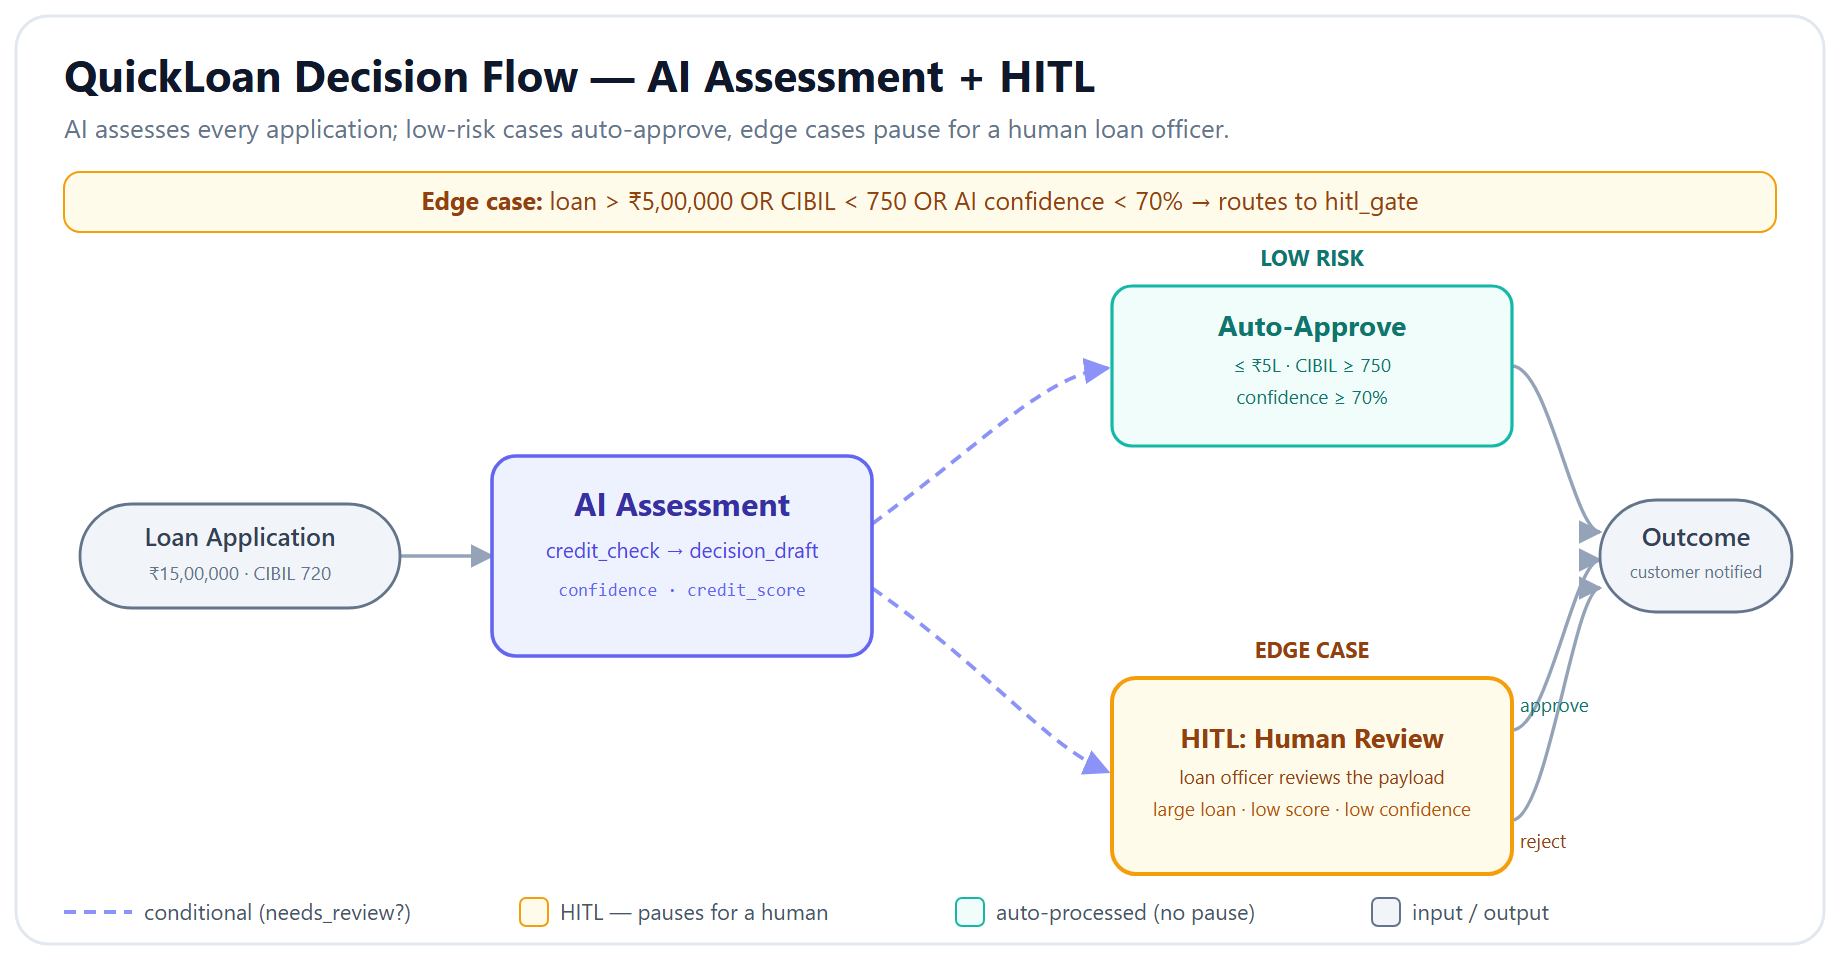

**Figure — QuickLoan decision flow.** AI assessment auto-approves low-risk applications; edge cases (loan > ₹5L, CIBIL < 750, or confidence < 70%) route to a human loan officer who approves or rejects.

## 4. Imports and Initialization

We import all LangGraph components upfront: `StateGraph` for the workflow, `interrupt` and `Command` for HITL, `InMemorySaver` for thread memory, and `InMemoryStore` for cross-session memory. `ChatOpenAI` provides the LLM with structured output via Pydantic.


In [3]:
import json
import uuid
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field

# LangGraph -- graph, HITL, memory
from langgraph.graph import StateGraph, START, END
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.store.memory import InMemoryStore

# LangChain -- LLM
from langchain_openai import ChatOpenAI

print("All imports loaded successfully")


All imports loaded successfully


## 5. State Definition

The state carries the full loan application through every node. Key design decisions:

| Field Group | Fields | Set By |
|-------------|--------|--------|
| Application inputs | `applicant_name`, `loan_amount`, `loan_purpose`, etc. | User input |
| Credit data | `credit_score`, `credit_report_summary`, `debt_to_income_ratio` | Credit check node |
| AI analysis | `ai_recommendation`, `ai_reasoning`, `ai_conditions`, `ai_confidence` | Decision draft node |
| Human decision | `human_decision` (dict) | HITL gate / auto-decision |
| Final output | `final_decision`, `final_response` | Final response node |
| Audit trail | `processing_log` (append-only list) | All nodes |


In [4]:
import operator

class LoanApprovalState(TypedDict):
    """State for the loan approval workflow."""
    # --- Application details (set by user input) ---
    applicant_name: str
    applicant_id: str
    loan_amount: float              # In INR
    loan_purpose: str
    annual_income: float
    employment_type: str            # salaried, self_employed, business

    # --- Credit check results ---
    credit_score: int
    credit_report_summary: str
    debt_to_income_ratio: float

    # --- AI recommendation ---
    ai_recommendation: str          # approve, reject, review
    ai_reasoning: str
    ai_conditions: list[str]
    ai_confidence: float            # 0.0 to 1.0

    # --- Human decision (populated by HITL gate or auto-decision) ---
    human_decision: dict            # {"approved": bool, "modified_amount": float,
                                    #  "conditions": [...], "officer_notes": str}

    # --- Final output ---
    final_decision: str
    final_response: str

    # --- Audit trail (append-only) ---
    processing_log: Annotated[list[str], operator.add]


print("LoanApprovalState schema defined")
print(f"Fields: {list(LoanApprovalState.__annotations__.keys())}")


LoanApprovalState schema defined
Fields: ['applicant_name', 'applicant_id', 'loan_amount', 'loan_purpose', 'annual_income', 'employment_type', 'credit_score', 'credit_report_summary', 'debt_to_income_ratio', 'ai_recommendation', 'ai_reasoning', 'ai_conditions', 'ai_confidence', 'human_decision', 'final_decision', 'final_response', 'processing_log']


## 6. Synthetic Banking Data

We create two databases:

1. **CUSTOMER_DATABASE** -- 5 customers with varied profiles for testing all code paths
2. **CREDIT_DATABASE** -- CIBIL scores and credit reports for each customer

| Customer | Loan (INR) | CIBIL | Expected Path |
|----------|-----------|-------|---------------|
| Rajesh Kumar | 3,00,000 | 810 | Auto-approve (small loan, excellent credit) |
| Priya Sharma | 15,00,000 | 720 | HITL (large loan, good but not excellent credit) |
| Vikram Singh | 2,00,000 | 420 | Auto-reject (very poor credit) |
| Anita Desai | 7,50,000 | 680 | HITL (medium loan, borderline credit) |
| Suresh Patel | 12,00,000 | 780 | HITL (large loan -- returning customer with history) |


In [5]:
# --- Customer database ---
CUSTOMER_DATABASE = {
    "CUST-001": {
        "name": "Rajesh Kumar",
        "loan_amount": 300000,        # INR 3 lakh
        "loan_purpose": "Home renovation",
        "annual_income": 1200000,     # INR 12 lakh
        "employment_type": "salaried",
    },
    "CUST-002": {
        "name": "Priya Sharma",
        "loan_amount": 1500000,       # INR 15 lakh
        "loan_purpose": "Business expansion - textile export",
        "annual_income": 2400000,     # INR 24 lakh
        "employment_type": "business",
    },
    "CUST-003": {
        "name": "Vikram Singh",
        "loan_amount": 200000,        # INR 2 lakh
        "loan_purpose": "Medical emergency",
        "annual_income": 360000,      # INR 3.6 lakh
        "employment_type": "self_employed",
    },
    "CUST-004": {
        "name": "Anita Desai",
        "loan_amount": 750000,        # INR 7.5 lakh
        "loan_purpose": "Vehicle purchase - commercial",
        "annual_income": 900000,      # INR 9 lakh
        "employment_type": "self_employed",
    },
    "CUST-005": {
        "name": "Suresh Patel",
        "loan_amount": 1200000,       # INR 12 lakh
        "loan_purpose": "Warehouse construction",
        "annual_income": 3600000,     # INR 36 lakh
        "employment_type": "business",
    },
}

# --- Credit database (CIBIL scores 300-900 range) ---
CREDIT_DATABASE = {
    "CUST-001": {
        "credit_score": 810,
        "existing_loans": 0,
        "existing_emi": 0,
        "defaults": 0,
        "credit_history_years": 8,
        "report_summary": "Excellent credit. No existing loans. 8-year clean history. "
                          "Zero defaults. CIBIL rank: A1.",
    },
    "CUST-002": {
        "credit_score": 720,
        "existing_loans": 1,
        "existing_emi": 25000,
        "defaults": 0,
        "credit_history_years": 5,
        "report_summary": "Good credit. One existing car loan (EMI INR 25,000). "
                          "5-year history. Zero defaults. CIBIL rank: B1.",
    },
    "CUST-003": {
        "credit_score": 420,
        "existing_loans": 3,
        "existing_emi": 18000,
        "defaults": 2,
        "credit_history_years": 3,
        "report_summary": "Poor credit. Three existing loans. Two defaults in last 12 months. "
                          "EMI burden INR 18,000 on INR 30,000 monthly income. CIBIL rank: D.",
    },
    "CUST-004": {
        "credit_score": 680,
        "existing_loans": 1,
        "existing_emi": 12000,
        "defaults": 0,
        "credit_history_years": 4,
        "report_summary": "Fair credit. One personal loan (EMI INR 12,000). "
                          "4-year history. Zero defaults but utilization is high. CIBIL rank: B2.",
    },
    "CUST-005": {
        "credit_score": 780,
        "existing_loans": 0,
        "existing_emi": 0,
        "defaults": 0,
        "credit_history_years": 12,
        "report_summary": "Very good credit. No existing loans. 12-year clean history. "
                          "Previous loan of INR 8 lakh fully repaid on time. CIBIL rank: A2.",
    },
}

# --- Customer history for cross-session memory (Customer 5 is returning) ---
CUSTOMER_HISTORY = {
    "CUST-005": [
        {
            "loan_id": "QL-2024-8821",
            "date": "2024-03-15",
            "amount": 800000,
            "purpose": "Equipment purchase",
            "status": "fully_repaid",
            "repayment_record": "All 12 EMIs paid on time",
            "officer_notes": "Reliable borrower. Business is growing steadily.",
        },
        {
            "loan_id": "QL-2023-4410",
            "date": "2023-01-10",
            "amount": 300000,
            "purpose": "Working capital",
            "status": "fully_repaid",
            "repayment_record": "All 6 EMIs paid on time",
            "officer_notes": "First-time borrower. Clean repayment.",
        },
    ]
}

print(f"Customer DB: {len(CUSTOMER_DATABASE)} customers")
print(f"Credit DB:   {len(CREDIT_DATABASE)} records")
print(f"History DB:  {len(CUSTOMER_HISTORY)} customers with past loans")


Customer DB: 5 customers
Credit DB:   5 records
History DB:  1 customers with past loans


## 7. LLM Initialization and Structured Output Schema

We use `gpt-4.1-mini` (non-reasoning model with temperature support) for both the decision draft and final response nodes. The `LoanRecommendation` Pydantic model ensures the LLM returns structured, validated output.

> **Why `gpt-4.1-mini` and not `gpt-5-mini`?** The decision draft needs `temperature=0.1` for deterministic classification. Reasoning models like `gpt-5-mini` do not support the `temperature` parameter.


In [6]:
# LLM -- gpt-4.1-mini supports temperature for deterministic classification
chat_model = ChatOpenAI(model="gpt-4.1-mini", temperature=0.1)

# Structured output schema for the AI recommendation
class LoanRecommendation(BaseModel):
    """AI recommendation for a loan application."""
    decision: str = Field(
        description="One of: approve, reject, review"
    )
    reasoning: str = Field(
        description="2-3 sentence explanation of the decision"
    )
    conditions: list[str] = Field(
        default_factory=list,
        description="Conditions for approval (empty if rejected)"
    )
    confidence: float = Field(
        ge=0.0, le=1.0,
        description="Confidence in the recommendation (0.0 to 1.0)"
    )
    suggested_amount: float = Field(
        description="Suggested loan amount in INR (may differ from requested)"
    )

# Bind structured output to the LLM
llm_with_structure = chat_model.with_structured_output(LoanRecommendation)

print("LLM initialized: gpt-4.1-mini (temperature=0.1)")
print(f"Structured output schema: {LoanRecommendation.__name__}")
print(f"  Fields: {list(LoanRecommendation.model_fields.keys())}")


LLM initialized: gpt-4.1-mini (temperature=0.1)
Structured output schema: LoanRecommendation
  Fields: ['decision', 'reasoning', 'conditions', 'confidence', 'suggested_amount']


## 8. Node 1: Credit Check

This node is a **pure data-lookup** -- no LLM call needed. It:

1. Looks up the customer's CIBIL score from `CREDIT_DATABASE`
2. Calculates the debt-to-income (DTI) ratio
3. Assembles the credit report summary

The DTI ratio is a key risk indicator: existing EMI payments divided by monthly income. A DTI above 50% is a red flag.


In [7]:
def credit_check_node(state: LoanApprovalState) -> dict:
    """Look up credit score and calculate debt-to-income ratio."""
    applicant_id = state["applicant_id"]
    credit_data = CREDIT_DATABASE.get(applicant_id, {})

    # Calculate debt-to-income ratio
    monthly_income = state["annual_income"] / 12
    existing_emi = credit_data.get("existing_emi", 0)
    dti_ratio = (existing_emi / monthly_income) if monthly_income > 0 else 1.0

    log_entry = (
        f"[Credit Check] CIBIL: {credit_data.get('credit_score', 'N/A')}, "
        f"DTI: {dti_ratio:.1%}, Existing EMI: INR {existing_emi:,.0f}"
    )

    return {
        "credit_score": credit_data.get("credit_score", 0),
        "credit_report_summary": credit_data.get("report_summary", "No credit data found"),
        "debt_to_income_ratio": round(dti_ratio, 3),
        "processing_log": [log_entry],
    }


# Quick test
test_state = {
    "applicant_id": "CUST-001",
    "annual_income": 1200000,
}
result = credit_check_node(test_state)
print(f"Credit score: {result['credit_score']}")
print(f"DTI ratio:    {result['debt_to_income_ratio']:.1%}")
print(f"Log:          {result['processing_log'][0]}")


Credit score: 810
DTI ratio:    0.0%
Log:          [Credit Check] CIBIL: 810, DTI: 0.0%, Existing EMI: INR 0


## 9. Node 2: AI Decision Draft

The LLM analyzes the application and credit data to produce a structured `LoanRecommendation`. The prompt includes all relevant data and the business rules, so the AI understands the thresholds.

This node **does not make the final decision** -- it drafts a recommendation that either gets auto-processed or sent to a human officer.


In [8]:
def decision_draft_node(state: LoanApprovalState) -> dict:
    """LLM drafts a loan recommendation with structured output."""
    prompt = (
        "You are a senior loan underwriter at QuickLoan, an Indian digital lending fintech.\n"
        "Analyze this loan application and provide your recommendation.\n\n"
        "APPLICATION DETAILS:\n"
        f"- Applicant: {state['applicant_name']}\n"
        f"- Loan Amount Requested: INR {state['loan_amount']:,.0f}\n"
        f"- Purpose: {state['loan_purpose']}\n"
        f"- Annual Income: INR {state['annual_income']:,.0f}\n"
        f"- Employment: {state['employment_type']}\n\n"
        "CREDIT REPORT:\n"
        f"- CIBIL Score: {state['credit_score']} (range: 300-900)\n"
        f"- Debt-to-Income Ratio: {state['debt_to_income_ratio']:.1%}\n"
        f"- Summary: {state['credit_report_summary']}\n\n"
        "BUSINESS RULES:\n"
        "- Auto-approve: Amount <= INR 5,00,000 AND CIBIL >= 750\n"
        "- Auto-reject: CIBIL < 500\n"
        "- Review needed: Amount > INR 5,00,000 OR CIBIL 500-749 OR high DTI (>50%)\n\n"
        "Provide your recommendation with decision, reasoning, conditions, confidence, "
        "and suggested_amount."
    )

    # Call LLM with structured output
    recommendation = llm_with_structure.invoke(prompt)

    log_entry = (
        f"[Decision Draft] AI recommends: {recommendation.decision} "
        f"(confidence: {recommendation.confidence:.0%}), "
        f"suggested amount: INR {recommendation.suggested_amount:,.0f}"
    )

    return {
        "ai_recommendation": recommendation.decision,
        "ai_reasoning": recommendation.reasoning,
        "ai_conditions": recommendation.conditions,
        "ai_confidence": recommendation.confidence,
        "processing_log": [log_entry],
    }


print("decision_draft_node defined -- uses structured output (LoanRecommendation)")


decision_draft_node defined -- uses structured output (LoanRecommendation)


## 10. The HITL Gate: `interrupt()` and `Command(resume=...)`

This is the **core of the lab**. The HITL gate checks three conditions:

| Condition | Threshold | Rationale |
|-----------|-----------|----------|
| Loan amount | > INR 5,00,000 | High-value loans need officer sign-off |
| Credit score | < 750 | Below "excellent" tier needs review |
| AI confidence | < 0.7 | Low-confidence recommendations need human judgment |

### How It Works

1. **If review is needed:** The node calls `interrupt(payload)` with a **rich dict** containing everything the human officer needs to decide. The graph **pauses** here.
2. **The human reviews** the payload and provides their decision as a dict.
3. **`Command(resume=decision)`** resumes the graph. The `interrupt()` call returns the human's decision.
4. **If no review needed:** The node auto-converts the AI recommendation into the same decision format and returns immediately (no pause).

### Key Technical Points

- `interrupt()` accepts any JSON-serializable value -- we send a rich payload
- The return value of `interrupt()` is whatever the human passes via `Command(resume=...)`
- A **checkpointer** (`MemorySaver`) is required -- it saves the graph state while paused
- A **thread_id** is required -- it identifies which paused graph to resume

> **WARNING:** Code before `interrupt()` re-runs on every resume. Keep side effects after the interrupt.


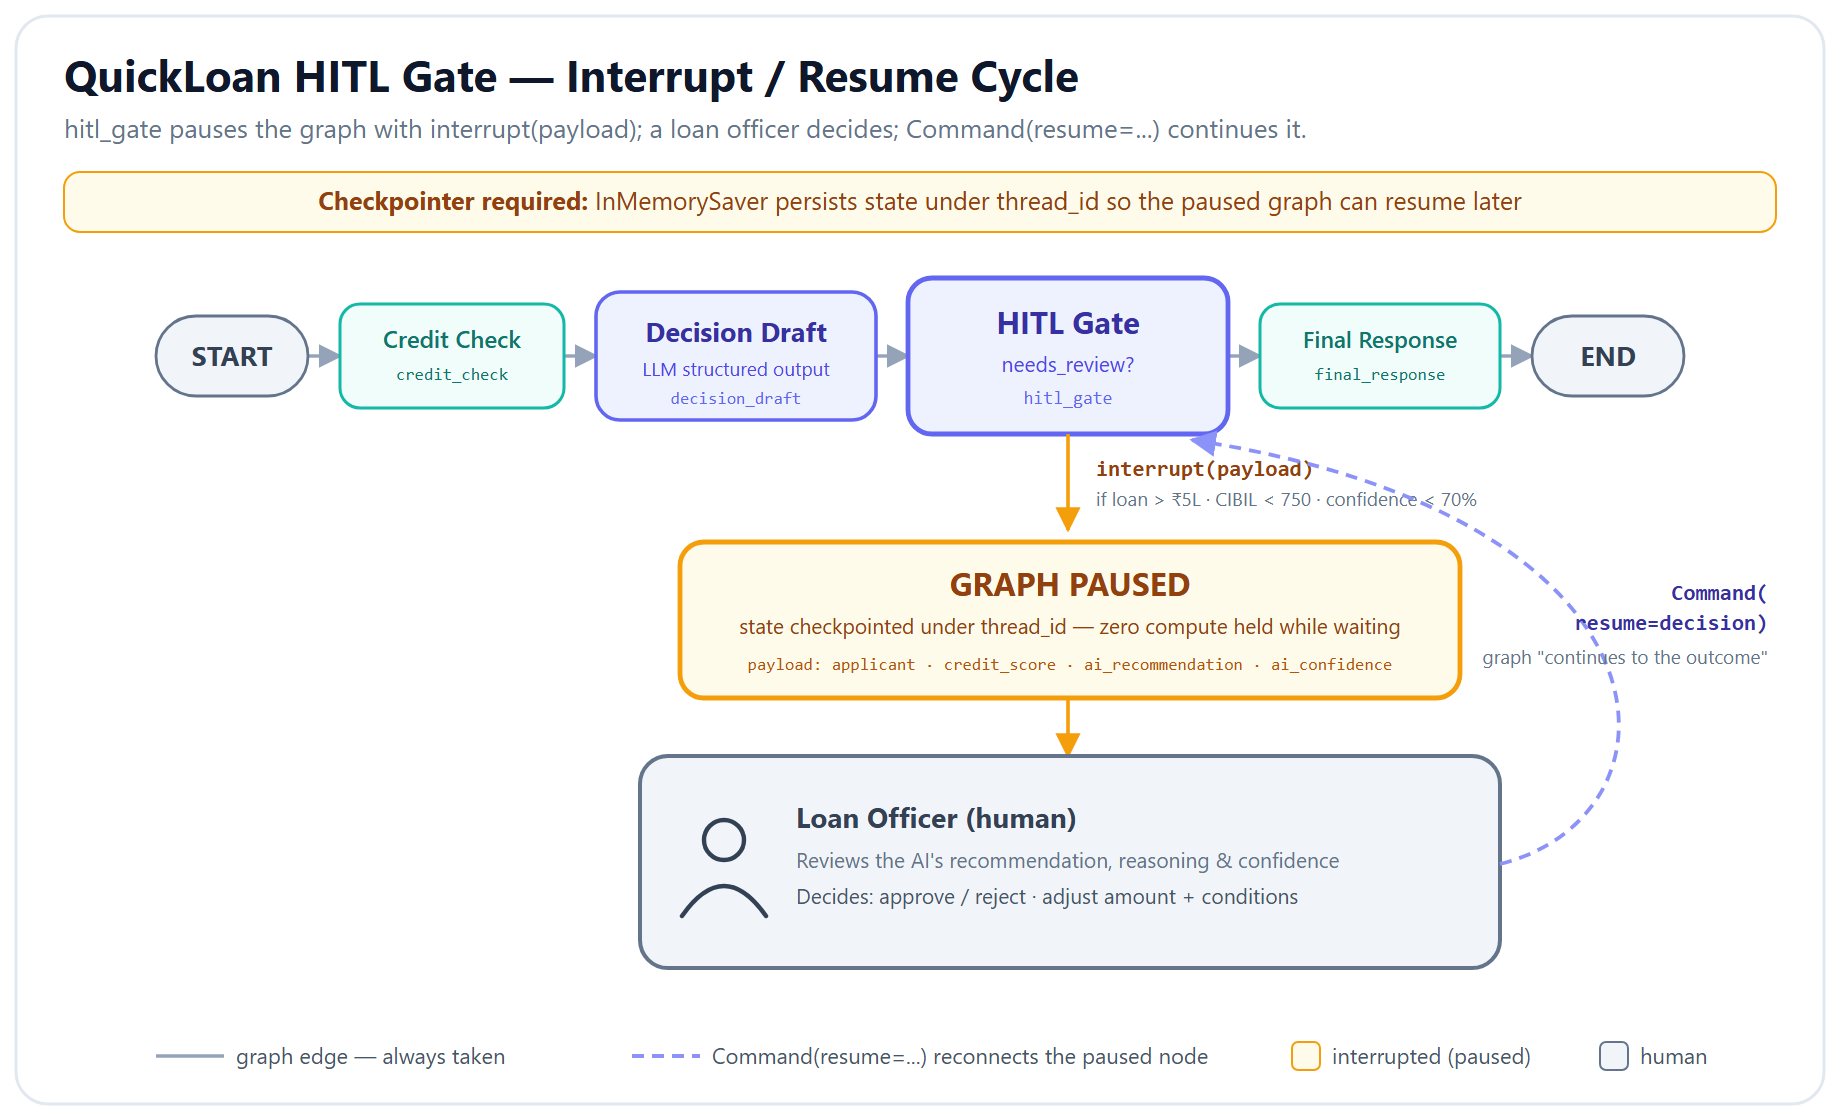

**Figure — HITL interrupt / resume cycle.** `hitl_gate` calls `interrupt(payload)` to pause the graph; the loan officer reviews the payload and decides; `Command(resume=decision)` resumes execution to `final_response`.

In [9]:
def hitl_gate(state: LoanApprovalState) -> dict:
    """Determine if human review is needed. If so, interrupt with a rich payload."""
    loan_amount = state["loan_amount"]
    credit_score = state["credit_score"]
    ai_confidence = state["ai_confidence"]
    ai_recommendation = state["ai_recommendation"]

    # --- Threshold logic ---
    needs_review = (
        loan_amount > 500000 or       # > INR 5 lakh
        credit_score < 750 or          # Below excellent tier
        ai_confidence < 0.7            # Low AI confidence
    )

    if needs_review:
        # Build a rich payload with everything the officer needs
        review_payload = {
            "type": "loan_review_required",
            "applicant": state["applicant_name"],
            "applicant_id": state["applicant_id"],
            "loan_amount": f"INR {loan_amount:,.0f}",
            "loan_amount_raw": loan_amount,
            "loan_purpose": state["loan_purpose"],
            "annual_income": f"INR {state['annual_income']:,.0f}",
            "employment_type": state["employment_type"],
            "credit_score": credit_score,
            "credit_report": state["credit_report_summary"],
            "dti_ratio": f"{state['debt_to_income_ratio']:.1%}",
            "ai_recommendation": ai_recommendation,
            "ai_reasoning": state["ai_reasoning"],
            "ai_conditions": state["ai_conditions"],
            "ai_confidence": f"{ai_confidence:.0%}",
            "message": (
                f"Loan of INR {loan_amount:,.0f} for {state['applicant_name']} "
                f"(CIBIL: {credit_score}) requires your review. "
                f"AI recommends: {ai_recommendation} (confidence: {ai_confidence:.0%})"
            ),
        }

        # --- PAUSE: interrupt() sends the payload and waits for human decision ---
        human_decision = interrupt(review_payload)

        log_entry = (
            f"[HITL Gate] HUMAN REVIEW completed. "
            f"Officer decision: {'APPROVED' if human_decision.get('approved') else 'REJECTED'}. "
            f"Notes: {human_decision.get('officer_notes', 'N/A')}"
        )
        return {
            "human_decision": human_decision,
            "processing_log": [log_entry],
        }
    else:
        # Auto-process: no human needed
        auto_decision = {
            "approved": ai_recommendation == "approve",
            "modified_amount": loan_amount,
            "conditions": state["ai_conditions"],
            "officer_notes": "Auto-processed (meets all criteria for automatic decision)",
        }
        log_entry = (
            f"[HITL Gate] Auto-processed: "
            f"{'APPROVED' if auto_decision['approved'] else 'REJECTED'} "
            f"(no human review needed)"
        )
        return {
            "human_decision": auto_decision,
            "processing_log": [log_entry],
        }


print("hitl_gate defined")
print("Thresholds: loan > INR 5L OR credit < 750 OR confidence < 70%")


hitl_gate defined
Thresholds: loan > INR 5L OR credit < 750 OR confidence < 70%


## 11. Node 3: Final Response Generator

The LLM generates a customer-facing response based on the final decision. This is a friendly, professional message that the customer receives via email or app notification.


In [10]:
def final_response_node(state: LoanApprovalState) -> dict:
    """Generate a customer-facing response based on the final decision."""
    decision = state["human_decision"]
    approved = decision.get("approved", False)
    final_decision = "APPROVED" if approved else "REJECTED"

    approved_amount_text = ""
    if approved:
        final_amount = decision.get("modified_amount", state["loan_amount"])
        approved_amount_text = f"Approved Amount: INR {final_amount:,.0f}"

    conditions_text = ", ".join(decision.get("conditions", [])) or "None"

    prompt = (
        "You are a customer communication specialist at QuickLoan.\n"
        "Write a brief, professional response to the customer about their loan application.\n\n"
        f"DECISION: {final_decision}\n"
        f"Applicant: {state['applicant_name']}\n"
        f"Requested Amount: INR {state['loan_amount']:,.0f}\n"
        f"{approved_amount_text}\n"
        f"Conditions: {conditions_text}\n"
        f"Officer Notes: {decision.get('officer_notes', 'N/A')}\n\n"
        "Write a 3-4 sentence response. Be empathetic if rejecting. Include next steps."
    )

    response = chat_model.invoke(prompt)

    log_entry = f"[Final Response] Decision: {final_decision}. Customer response generated."

    return {
        "final_decision": final_decision,
        "final_response": response.content,
        "processing_log": [log_entry],
    }


print("final_response_node defined -- generates customer-facing message")


final_response_node defined -- generates customer-facing message


## 12. Build the Graph with MemorySaver

We compile the graph with a `MemorySaver` checkpointer. This is required for:
1. **HITL:** The graph must save its state when `interrupt()` pauses it
2. **Thread memory:** Each thread_id maintains its own conversation state

| Component | Role |
|-----------|------|
| `MemorySaver` | Saves graph state at each super-step (required for interrupt/resume) |
| `thread_id` | Identifies which conversation/state to resume |

> **Production note:** Replace `InMemorySaver` with `PostgresSaver` or `SqliteSaver` for persistence across restarts.


> **`MemorySaver` or `InMemorySaver`?** The same class. `InMemorySaver` is its current name; `MemorySaver` is kept as an alias, which is why older tutorials — and this workshop's curriculum — use it. Both import from `langgraph.checkpoint.memory`.

In [11]:
# Build the StateGraph
builder = StateGraph(LoanApprovalState)

# Add nodes
builder.add_node("credit_check", credit_check_node)
builder.add_node("decision_draft", decision_draft_node)
builder.add_node("hitl_gate", hitl_gate)
builder.add_node("final_response", final_response_node)

# Add edges -- linear pipeline
builder.add_edge(START, "credit_check")
builder.add_edge("credit_check", "decision_draft")
builder.add_edge("decision_draft", "hitl_gate")
builder.add_edge("hitl_gate", "final_response")
builder.add_edge("final_response", END)

# Compile with MemorySaver (required for interrupt/resume and thread memory)
memory = InMemorySaver()
graph = builder.compile(checkpointer=memory)

print("Graph compiled with MemorySaver checkpointer")
print(f"Nodes: {list(builder.nodes.keys())}")


Graph compiled with MemorySaver checkpointer
Nodes: ['credit_check', 'decision_draft', 'hitl_gate', 'final_response']


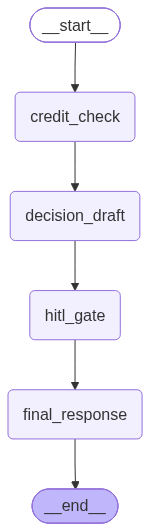

In [12]:
# Visualize the graph
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as error:
    # Fallback: print the Mermaid diagram text
    print("Graph structure (Mermaid):")
    print(graph.get_graph().draw_mermaid())


> ⏭️ **After the session.** This section is not run live in the workshop. Work through it afterwards, top to bottom.

## 13. Test Case 1: Auto-Approve (Small Loan, Excellent Credit)

**Customer:** Rajesh Kumar
**Loan:** INR 3,00,000 (3 lakh) -- below the INR 5 lakh threshold
**CIBIL:** 810 -- excellent (above 750)

**Expected behavior:** The graph should flow straight through **without pausing** at the HITL gate. The AI recommends approval, and since all thresholds are met, it auto-approves.

```
START --> credit_check --> decision_draft --> hitl_gate (auto) --> final_response --> END
```


In [13]:
# Test Case 1: Auto-approve -- should flow straight through
customer = CUSTOMER_DATABASE["CUST-001"]
config_1 = {"configurable": {"thread_id": "loan-001"}}

input_state = {
    "applicant_name": customer["name"],
    "applicant_id": "CUST-001",
    "loan_amount": customer["loan_amount"],
    "loan_purpose": customer["loan_purpose"],
    "annual_income": customer["annual_income"],
    "employment_type": customer["employment_type"],
    # Initialize empty fields
    "credit_score": 0,
    "credit_report_summary": "",
    "debt_to_income_ratio": 0.0,
    "ai_recommendation": "",
    "ai_reasoning": "",
    "ai_conditions": [],
    "ai_confidence": 0.0,
    "human_decision": {},
    "final_decision": "",
    "final_response": "",
    "processing_log": [],
}

# Invoke -- this should complete without interruption
result = graph.invoke(input_state, config=config_1)

print("=" * 70)
print(f"APPLICANT: {result['applicant_name']}")
print(f"LOAN:      INR {result['loan_amount']:,.0f}")
print(f"CIBIL:     {result['credit_score']}")
print(f"AI:        {result['ai_recommendation']} (confidence: {result['ai_confidence']:.0%})")
print(f"DECISION:  {result['final_decision']}")
print("-" * 70)
print("PROCESSING LOG:")
for log_entry in result["processing_log"]:
    print(f"  {log_entry}")
print("-" * 70)
print("CUSTOMER RESPONSE:")
print(result["final_response"])
print("=" * 70)


APPLICANT: Rajesh Kumar
LOAN:      INR 300,000
CIBIL:     810
AI:        approve (confidence: 95%)
DECISION:  APPROVED
----------------------------------------------------------------------
PROCESSING LOG:
  [Credit Check] CIBIL: 810, DTI: 0.0%, Existing EMI: INR 0
  [Decision Draft] AI recommends: approve (confidence: 95%), suggested amount: INR 300,000
  [HITL Gate] Auto-processed: APPROVED (no human review needed)
  [Final Response] Decision: APPROVED. Customer response generated.
----------------------------------------------------------------------
CUSTOMER RESPONSE:
Dear Mr. Kumar,

We are pleased to inform you that your loan application for INR 300,000 has been approved for the purpose of home renovation. To proceed with the disbursement, please provide valid identification and address proof at your earliest convenience. Should you have any questions or need assistance, feel free to contact us. We look forward to supporting your home improvement plans.


## 14. Test Case 2: HITL Triggered (Large Loan)

**Customer:** Priya Sharma
**Loan:** INR 15,00,000 (15 lakh) -- well above the INR 5 lakh threshold
**CIBIL:** 720 -- good but below 750

**Expected behavior:** The graph will **pause** at the HITL gate. We then:

1. **Invoke** the graph -- it runs through credit_check and decision_draft, then **pauses**
2. **Inspect** the interrupt payload to see what the AI recommends
3. **Provide** a human decision (approve with conditions, reduced amount)
4. **Resume** with `Command(resume=decision)` -- the graph completes

This is the **core HITL flow** -- pay close attention to each step.

```
START --> credit_check --> decision_draft --> hitl_gate --> [PAUSED]
                                                              |
                                          Human reviews + decides
                                                              |
                                          Command(resume=decision)
                                                              |
                                                        final_response --> END
```


In [14]:
# ===========================================================================
# STEP 1: Invoke the graph -- it will PAUSE at the HITL gate
# ===========================================================================
customer = CUSTOMER_DATABASE["CUST-002"]
config_2 = {"configurable": {"thread_id": "loan-002"}}

input_state_2 = {
    "applicant_name": customer["name"],
    "applicant_id": "CUST-002",
    "loan_amount": customer["loan_amount"],
    "loan_purpose": customer["loan_purpose"],
    "annual_income": customer["annual_income"],
    "employment_type": customer["employment_type"],
    "credit_score": 0, "credit_report_summary": "", "debt_to_income_ratio": 0.0,
    "ai_recommendation": "", "ai_reasoning": "", "ai_conditions": [],
    "ai_confidence": 0.0, "human_decision": {}, "final_decision": "",
    "final_response": "", "processing_log": [],
}

# This invoke will NOT complete -- it pauses at the interrupt
result_partial = graph.invoke(input_state_2, config=config_2)

print("[STEP 1] Graph invoked -- it should have paused at the HITL gate")
print(f"  Result keys present: {list(result_partial.keys())}")


[STEP 1] Graph invoked -- it should have paused at the HITL gate
  Result keys present: ['applicant_name', 'applicant_id', 'loan_amount', 'loan_purpose', 'annual_income', 'employment_type', 'credit_score', 'credit_report_summary', 'debt_to_income_ratio', 'ai_recommendation', 'ai_reasoning', 'ai_conditions', 'ai_confidence', 'human_decision', 'final_decision', 'final_response', 'processing_log', '__interrupt__']


In [15]:
# ===========================================================================
# STEP 2: Inspect the interrupt payload -- what the human officer sees
# ===========================================================================
state_snapshot = graph.get_state(config_2)

print(f"Graph paused at node(s): {state_snapshot.next}")
print()

# The interrupt payload is in state_snapshot.tasks[0].interrupts[0].value
if state_snapshot.tasks and state_snapshot.tasks[0].interrupts:
    interrupt_payload = state_snapshot.tasks[0].interrupts[0].value
    print("=" * 70)
    print("LOAN REVIEW REQUEST -- For Human Officer")
    print("=" * 70)
    print(json.dumps(interrupt_payload, indent=2, ensure_ascii=False))
    print("=" * 70)
else:
    print("No interrupt found -- graph may have completed without pausing")


Graph paused at node(s): ('hitl_gate',)

LOAN REVIEW REQUEST -- For Human Officer
{
  "type": "loan_review_required",
  "applicant": "Priya Sharma",
  "applicant_id": "CUST-002",
  "loan_amount": "INR 1,500,000",
  "loan_amount_raw": 1500000,
  "loan_purpose": "Business expansion - textile export",
  "annual_income": "INR 2,400,000",
  "employment_type": "business",
  "credit_score": 720,
  "credit_report": "Good credit. One existing car loan (EMI INR 25,000). 5-year history. Zero defaults. CIBIL rank: B1.",
  "dti_ratio": "12.5%",
  "ai_recommendation": "review",
  "ai_reasoning": "The applicant has a good credit score of 720 and a low debt-to-income ratio of 12.5%, indicating financial stability. However, the requested loan amount of INR 1,500,000 exceeds the auto-approval limit of INR 500,000, necessitating a manual review as per business rules.",
  "ai_conditions": [
    "Provide detailed business financial statements for the last 2 years",
    "Submit a comprehensive business expa

In [16]:
# ===========================================================================
# STEP 3: Human officer provides their decision
# ===========================================================================

# The officer reviews the AI recommendation and decides:
# - Approve, but reduce amount from INR 15L to INR 12L (DTI concern)
# - Add conditions for verification
human_decision = {
    "approved": True,
    "modified_amount": 1200000,  # Reduced from 15L to 12L
    "conditions": [
        "Latest 6 months salary slips required",
        "Business registration certificate to be verified",
        "Property valuation report needed for collateral",
    ],
    "officer_notes": (
        "Approved at reduced amount of INR 12,00,000. "
        "Good credit history but DTI will be stretched at full amount. "
        "Business expansion purpose is valid -- textile export has good margins."
    ),
}

print("[STEP 3] Human officer decision:")
print(json.dumps(human_decision, indent=2))

# ===========================================================================
# STEP 4: Resume the graph with Command(resume=...)
# ===========================================================================
print()
print("[STEP 4] Resuming graph with Command(resume=decision)...")
print()

result_final = graph.invoke(
    Command(resume=human_decision),
    config=config_2,  # Same thread_id to resume the paused graph
)

print("=" * 70)
print(f"APPLICANT: {result_final['applicant_name']}")
print(f"LOAN:      INR {result_final['loan_amount']:,.0f}")
print(f"CIBIL:     {result_final['credit_score']}")
print(f"AI:        {result_final['ai_recommendation']} (confidence: {result_final['ai_confidence']:.0%})")
print(f"DECISION:  {result_final['final_decision']}")
print("-" * 70)
print("PROCESSING LOG:")
for log_entry in result_final["processing_log"]:
    print(f"  {log_entry}")
print("-" * 70)
print("CUSTOMER RESPONSE:")
print(result_final["final_response"])
print("=" * 70)


[STEP 3] Human officer decision:
{
  "approved": true,
  "modified_amount": 1200000,
  "conditions": [
    "Latest 6 months salary slips required",
    "Business registration certificate to be verified",
    "Property valuation report needed for collateral"
  ],
  "officer_notes": "Approved at reduced amount of INR 12,00,000. Good credit history but DTI will be stretched at full amount. Business expansion purpose is valid -- textile export has good margins."
}

[STEP 4] Resuming graph with Command(resume=decision)...



APPLICANT: Priya Sharma
LOAN:      INR 1,500,000
CIBIL:     720
AI:        review (confidence: 85%)
DECISION:  APPROVED
----------------------------------------------------------------------
PROCESSING LOG:
  [Credit Check] CIBIL: 720, DTI: 12.5%, Existing EMI: INR 25,000
  [Decision Draft] AI recommends: review (confidence: 85%), suggested amount: INR 1,500,000
  [HITL Gate] HUMAN REVIEW completed. Officer decision: APPROVED. Notes: Approved at reduced amount of INR 12,00,000. Good credit history but DTI will be stretched at full amount. Business expansion purpose is valid -- textile export has good margins.
  [Final Response] Decision: APPROVED. Customer response generated.
----------------------------------------------------------------------
CUSTOMER RESPONSE:
Dear Priya Sharma,

We are pleased to inform you that your loan application has been approved for INR 1,200,000. To proceed, please provide your latest six months’ salary slips, your business registration certificate for veri

> ⏭️ **After the session.** This section is not run live in the workshop. Work through it afterwards, top to bottom.

## 15. Test Case 3: HITL with Rejection (Poor Credit)

**Customer:** Vikram Singh
**Loan:** INR 2,00,000 (2 lakh) -- small loan
**CIBIL:** 420 -- very poor (below 500)

**Expected behavior:** The AI should recommend rejection. Since CIBIL < 750, the HITL gate **will trigger**. The officer confirms the rejection.


In [17]:
# Test Case 3: Poor credit -- HITL triggers (credit < 750), officer rejects
customer = CUSTOMER_DATABASE["CUST-003"]
config_3 = {"configurable": {"thread_id": "loan-003"}}

input_state_3 = {
    "applicant_name": customer["name"],
    "applicant_id": "CUST-003",
    "loan_amount": customer["loan_amount"],
    "loan_purpose": customer["loan_purpose"],
    "annual_income": customer["annual_income"],
    "employment_type": customer["employment_type"],
    "credit_score": 0, "credit_report_summary": "", "debt_to_income_ratio": 0.0,
    "ai_recommendation": "", "ai_reasoning": "", "ai_conditions": [],
    "ai_confidence": 0.0, "human_decision": {}, "final_decision": "",
    "final_response": "", "processing_log": [],
}

# Step 1: Invoke -- will pause at HITL gate
result_3 = graph.invoke(input_state_3, config=config_3)

# Step 2: Check interrupt
state_3 = graph.get_state(config_3)
if state_3.tasks and state_3.tasks[0].interrupts:
    payload = state_3.tasks[0].interrupts[0].value
    print(f"Review request: {payload['message']}")
    print()

    # Step 3: Officer confirms rejection
    reject_decision = {
        "approved": False,
        "modified_amount": 0,
        "conditions": [],
        "officer_notes": (
            "Rejected. Two defaults in last 12 months. "
            "DTI is extremely high at 60%. "
            "Advise customer to clear existing defaults and reapply after 6 months."
        ),
    }

    # Step 4: Resume with rejection
    result_3_final = graph.invoke(
        Command(resume=reject_decision),
        config=config_3,
    )

    print("=" * 70)
    print(f"DECISION: {result_3_final['final_decision']}")
    print("-" * 70)
    print("CUSTOMER RESPONSE:")
    print(result_3_final["final_response"])
    print("=" * 70)
else:
    print("Graph completed without interrupt (unexpected for this test case)")


Review request: Loan of INR 200,000 for Vikram Singh (CIBIL: 420) requires your review. AI recommends: reject (confidence: 95%)



DECISION: REJECTED
----------------------------------------------------------------------
CUSTOMER RESPONSE:
Dear Mr. Singh,

Thank you for your loan application. After careful review, we regret to inform you that your request for INR 200,000 has been declined due to recent defaults and a high debt-to-income ratio. We encourage you to clear the existing defaults and consider reapplying after six months. Please feel free to reach out if you have any questions or need assistance.


## 16. Thread Memory with MemorySaver

The `MemorySaver` checkpointer automatically provides **thread-based memory**. Every graph invocation with the same `thread_id` shares state.

| Feature | How It Works |
|---------|--------------|
| State persistence | Graph state saved at every super-step |
| Resume after pause | Same thread_id resumes from where it paused |
| State history | `get_state_history()` returns all checkpoints for a thread |
| Time travel | Can replay from any previous checkpoint |

Let us inspect the state history for Test Case 2 (Priya Sharma) to see every checkpoint.


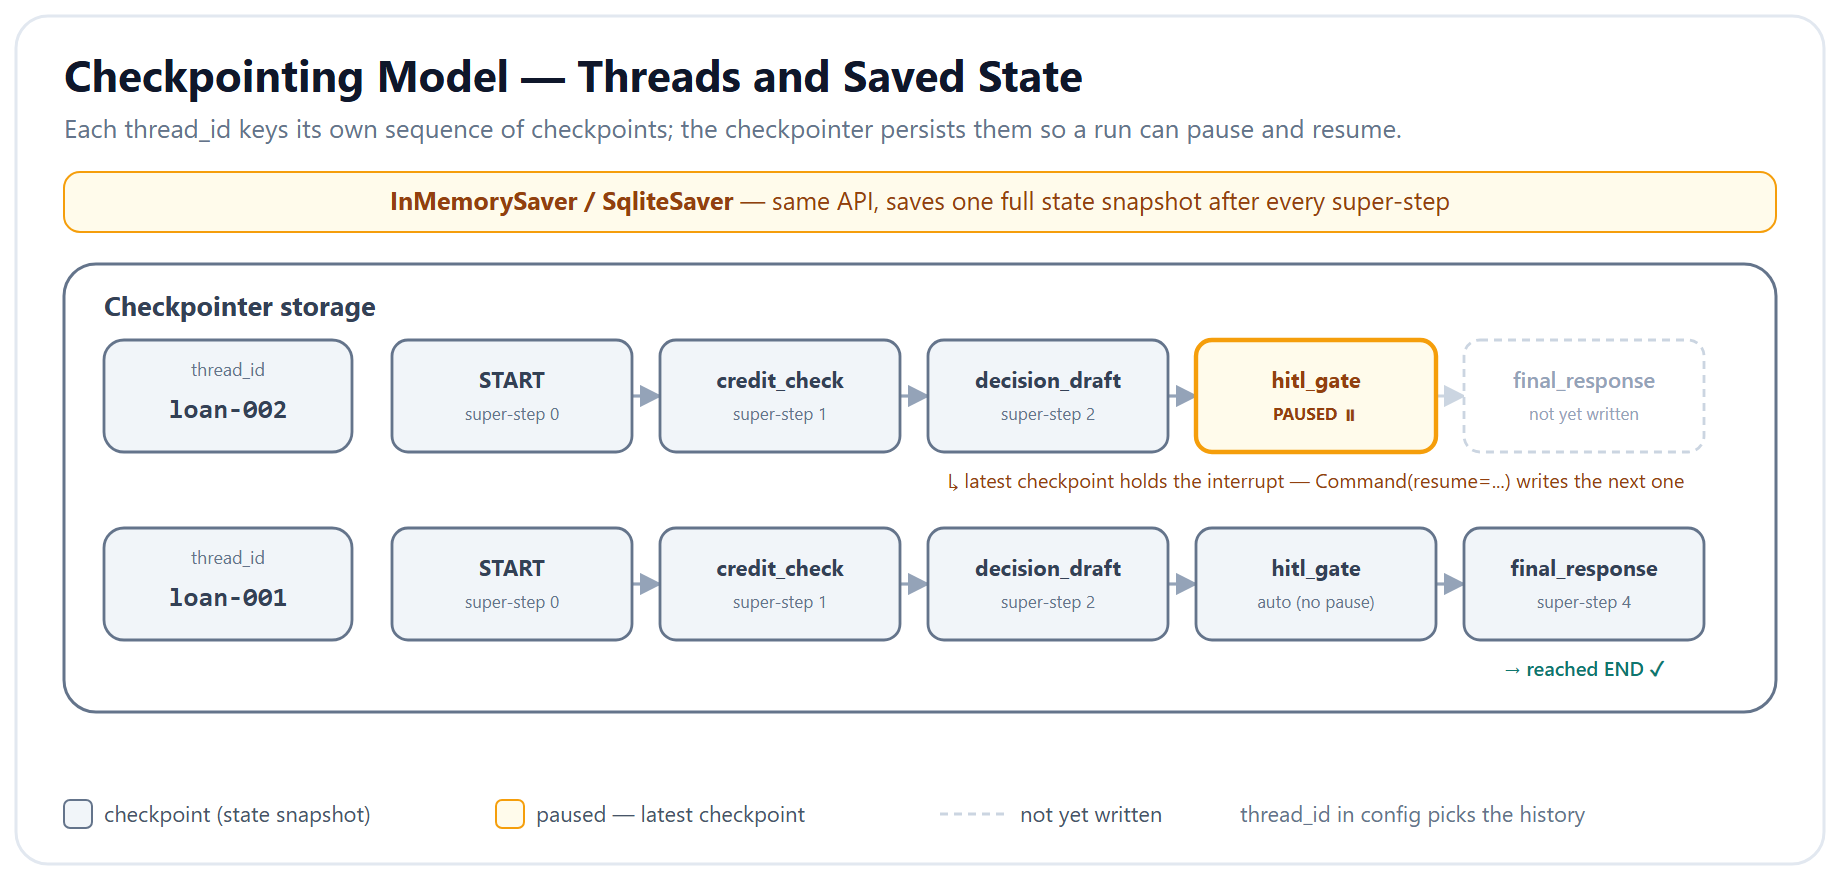

**Figure — Checkpointing model.** Each `thread_id` keys its own sequence of checkpoints, one per super-step; a paused thread's latest checkpoint holds the interrupt until `Command(resume=...)` writes the next one.

In [18]:
# Inspect state history for Test Case 2 (thread: loan-002)
config_history = {"configurable": {"thread_id": "loan-002"}}

print("STATE HISTORY for thread 'loan-002' (Priya Sharma)")
print("=" * 70)

history = list(graph.get_state_history(config_history))
for checkpoint_offset, snapshot in enumerate(history):
    step = snapshot.metadata.get("step", "?")
    source = snapshot.metadata.get("source", "?")
    writes = snapshot.metadata.get("writes", {})
    node_names = list(writes.keys()) if writes else ["(input)"]

    print(f"Checkpoint {len(history) - checkpoint_offset}: step={step}, source={source}, "
          f"nodes={node_names}, next={snapshot.next}")

print(f"\nTotal checkpoints: {len(history)}")
print("Each checkpoint is a full snapshot of the graph state at that super-step.")


STATE HISTORY for thread 'loan-002' (Priya Sharma)
Checkpoint 6: step=4, source=loop, nodes=['(input)'], next=()
Checkpoint 5: step=3, source=loop, nodes=['(input)'], next=('final_response',)
Checkpoint 4: step=2, source=loop, nodes=['(input)'], next=('hitl_gate',)
Checkpoint 3: step=1, source=loop, nodes=['(input)'], next=('decision_draft',)
Checkpoint 2: step=0, source=loop, nodes=['(input)'], next=('credit_check',)
Checkpoint 1: step=-1, source=input, nodes=['(input)'], next=('__start__',)

Total checkpoints: 6
Each checkpoint is a full snapshot of the graph state at that super-step.


## 17. Cross-Session Memory with InMemoryStore

`MemorySaver` gives us thread-based memory -- it remembers within a conversation. But what about remembering a customer **across different sessions**?

| Memory Type | Scope | API | Use Case |
|-------------|-------|-----|----------|
| `MemorySaver` (checkpointer) | Within a thread | `thread_id` in config | Conversation context, interrupt/resume |
| `InMemoryStore` (store) | Across all threads | Namespace tuples + keys | Customer history, preferences |

`InMemoryStore` provides a **key-value store** organized by namespaces. We use it to store and retrieve customer loan history across sessions.

### How It Works

```python
store = InMemoryStore()

# Store data under a namespace
store.put(("customers", "CUST-005"), "loan-history", {"loans": [...]})

# Retrieve from any thread
items = store.search(("customers", "CUST-005"))
```

> **Production note:** Replace `InMemoryStore` with `PostgresStore` or `RedisStore` for persistence across restarts.


In [19]:
# Initialize the cross-session store
store = InMemoryStore()

# --- Populate the store with customer history ---
# Namespace: ("customers", customer_id, "loan_history")
for customer_id, loans in CUSTOMER_HISTORY.items():
    namespace = ("customers", customer_id, "loan_history")
    for loan in loans:
        store.put(namespace, loan["loan_id"], loan)

print("InMemoryStore populated with customer history")
print()

# --- Retrieve history for a customer (works from ANY thread) ---
namespace = ("customers", "CUST-005", "loan_history")
items = store.search(namespace)

print(f"Customer CUST-005 (Suresh Patel) -- Loan History:")
print("=" * 70)
for item in items:
    loan = item.value
    print(f"  Loan ID:    {loan['loan_id']}")
    print(f"  Date:       {loan['date']}")
    print(f"  Amount:     INR {loan['amount']:,.0f}")
    print(f"  Purpose:    {loan['purpose']}")
    print(f"  Status:     {loan['status']}")
    print(f"  Repayment:  {loan['repayment_record']}")
    print(f"  Notes:      {loan['officer_notes']}")
    print("-" * 40)


InMemoryStore populated with customer history

Customer CUST-005 (Suresh Patel) -- Loan History:
  Loan ID:    QL-2024-8821
  Date:       2024-03-15
  Amount:     INR 800,000
  Purpose:    Equipment purchase
  Status:     fully_repaid
  Repayment:  All 12 EMIs paid on time
  Notes:      Reliable borrower. Business is growing steadily.
----------------------------------------
  Loan ID:    QL-2023-4410
  Date:       2023-01-10
  Amount:     INR 300,000
  Purpose:    Working capital
  Status:     fully_repaid
  Repayment:  All 6 EMIs paid on time
  Notes:      First-time borrower. Clean repayment.
----------------------------------------


> ⏭️ **After the session.** This section is not run live in the workshop. Work through it afterwards, top to bottom.

## 18. Using Cross-Session Memory in the Graph

Now we rebuild the graph with the `InMemoryStore` attached. The decision-draft node will check if the customer has prior loan history and factor it into the recommendation.

We compile the graph with **both** the checkpointer (for HITL + thread memory) and the store (for cross-session memory).


In [20]:
def decision_draft_with_memory(state: LoanApprovalState, *, store) -> dict:
    """Enhanced decision draft that checks cross-session customer history."""

    # --- Check cross-session memory for customer history ---
    customer_id = state["applicant_id"]
    namespace = ("customers", customer_id, "loan_history")
    history_items = store.search(namespace)

    history_context = ""
    if history_items:
        history_lines = []
        for item in history_items:
            loan = item.value
            history_lines.append(
                f"- {loan['date']}: INR {loan['amount']:,.0f} for {loan['purpose']} "
                f"({loan['status']}, {loan['repayment_record']})"
            )
        history_context = (
            f"\nCUSTOMER HISTORY (returning customer -- {len(history_items)} past loans):\n"
            + "\n".join(history_lines)
            + "\nThis is a returning customer with a track record. Factor this into your assessment."
        )
    else:
        history_context = "\nCUSTOMER HISTORY: First-time applicant. No prior loan history."

    prompt = (
        "You are a senior loan underwriter at QuickLoan, an Indian digital lending fintech.\n"
        "Analyze this loan application and provide your recommendation.\n\n"
        "APPLICATION DETAILS:\n"
        f"- Applicant: {state['applicant_name']}\n"
        f"- Loan Amount Requested: INR {state['loan_amount']:,.0f}\n"
        f"- Purpose: {state['loan_purpose']}\n"
        f"- Annual Income: INR {state['annual_income']:,.0f}\n"
        f"- Employment: {state['employment_type']}\n\n"
        "CREDIT REPORT:\n"
        f"- CIBIL Score: {state['credit_score']} (range: 300-900)\n"
        f"- Debt-to-Income Ratio: {state['debt_to_income_ratio']:.1%}\n"
        f"- Summary: {state['credit_report_summary']}"
        f"{history_context}\n\n"
        "BUSINESS RULES:\n"
        "- Auto-approve: Amount <= INR 5,00,000 AND CIBIL >= 750\n"
        "- Auto-reject: CIBIL < 500\n"
        "- Review needed: Amount > INR 5,00,000 OR CIBIL 500-749 OR high DTI (>50%)\n\n"
        "Provide your recommendation with decision, reasoning, conditions, confidence, "
        "and suggested_amount."
    )

    recommendation = llm_with_structure.invoke(prompt)

    log_entry = (
        f"[Decision Draft] AI recommends: {recommendation.decision} "
        f"(confidence: {recommendation.confidence:.0%}). "
        f"Customer history: {'returning customer' if history_items else 'first-time applicant'}"
    )

    return {
        "ai_recommendation": recommendation.decision,
        "ai_reasoning": recommendation.reasoning,
        "ai_conditions": recommendation.conditions,
        "ai_confidence": recommendation.confidence,
        "processing_log": [log_entry],
    }


# Rebuild graph with store support
builder_v2 = StateGraph(LoanApprovalState)
builder_v2.add_node("credit_check", credit_check_node)
builder_v2.add_node("decision_draft", decision_draft_with_memory)
builder_v2.add_node("hitl_gate", hitl_gate)
builder_v2.add_node("final_response", final_response_node)

builder_v2.add_edge(START, "credit_check")
builder_v2.add_edge("credit_check", "decision_draft")
builder_v2.add_edge("decision_draft", "hitl_gate")
builder_v2.add_edge("hitl_gate", "final_response")
builder_v2.add_edge("final_response", END)

# Compile with BOTH checkpointer and store
memory_v2 = InMemorySaver()
graph_v2 = builder_v2.compile(checkpointer=memory_v2, store=store)

print("Graph v2 compiled with MemorySaver + InMemoryStore")


Graph v2 compiled with MemorySaver + InMemoryStore


## 19. Test Case 4: Returning Customer (Cross-Session Memory)

**Customer:** Suresh Patel (CUST-005)
**Loan:** INR 12,00,000 (12 lakh) -- large loan, triggers HITL
**CIBIL:** 780 -- very good
**History:** 2 previous loans, both fully repaid on time

**Expected behavior:** The decision draft node should retrieve Suresh's loan history from `InMemoryStore` and factor it into the recommendation. The AI should give higher confidence because of the clean repayment history.


In [21]:
# Test Case 4: Returning customer with cross-session memory
customer = CUSTOMER_DATABASE["CUST-005"]
config_5 = {"configurable": {"thread_id": "loan-005"}}

input_state_5 = {
    "applicant_name": customer["name"],
    "applicant_id": "CUST-005",
    "loan_amount": customer["loan_amount"],
    "loan_purpose": customer["loan_purpose"],
    "annual_income": customer["annual_income"],
    "employment_type": customer["employment_type"],
    "credit_score": 0, "credit_report_summary": "", "debt_to_income_ratio": 0.0,
    "ai_recommendation": "", "ai_reasoning": "", "ai_conditions": [],
    "ai_confidence": 0.0, "human_decision": {}, "final_decision": "",
    "final_response": "", "processing_log": [],
}

# Step 1: Invoke -- will pause at HITL gate (loan > 5L)
result_5 = graph_v2.invoke(input_state_5, config=config_5)

# Step 2: Inspect interrupt
state_5 = graph_v2.get_state(config_5)
if state_5.tasks and state_5.tasks[0].interrupts:
    payload = state_5.tasks[0].interrupts[0].value
    print("REVIEW REQUEST:")
    print(f"  {payload['message']}")
    print(f"  AI reasoning: {state_5.values.get('ai_reasoning', 'N/A')}")
    print()

    # Step 3: Officer approves (returning customer with clean history!)
    approve_decision = {
        "approved": True,
        "modified_amount": 1200000,  # Full amount approved
        "conditions": [
            "Standard documentation package",
            "Warehouse site inspection required",
        ],
        "officer_notes": (
            "Approved at full amount. Returning customer with excellent repayment "
            "history (2 previous loans, all paid on time). Strong CIBIL and income."
        ),
    }

    # Step 4: Resume
    result_5_final = graph_v2.invoke(
        Command(resume=approve_decision),
        config=config_5,
    )

    print("=" * 70)
    print(f"APPLICANT: {result_5_final['applicant_name']}")
    print(f"DECISION:  {result_5_final['final_decision']}")
    print("-" * 70)
    print("PROCESSING LOG:")
    for log_entry in result_5_final["processing_log"]:
        print(f"  {log_entry}")
    print("-" * 70)
    print("CUSTOMER RESPONSE:")
    print(result_5_final["final_response"])
    print("=" * 70)


REVIEW REQUEST:
  Loan of INR 1,200,000 for Suresh Patel (CIBIL: 780) requires your review. AI recommends: review (confidence: 90%)
  AI reasoning: The applicant has a strong credit profile with a high CIBIL score of 780, zero debt-to-income ratio, and a solid repayment history as a returning customer. However, the requested loan amount of INR 1,200,000 exceeds the auto-approval threshold, necessitating a manual review to assess the business viability and repayment capacity for the warehouse construction purpose.



APPLICANT: Suresh Patel
DECISION:  APPROVED
----------------------------------------------------------------------
PROCESSING LOG:
  [Credit Check] CIBIL: 780, DTI: 0.0%, Existing EMI: INR 0
  [Decision Draft] AI recommends: review (confidence: 90%). Customer history: returning customer
  [HITL Gate] HUMAN REVIEW completed. Officer decision: APPROVED. Notes: Approved at full amount. Returning customer with excellent repayment history (2 previous loans, all paid on time). Strong CIBIL and income.
  [Final Response] Decision: APPROVED. Customer response generated.
----------------------------------------------------------------------
CUSTOMER RESPONSE:
Dear Mr. Patel,

We are pleased to inform you that your loan application for INR 1,200,000 has been approved in full. As a returning customer with an excellent repayment history and strong financial standing, we appreciate your continued trust in QuickLoan. The next steps include submitting the standard documentation package and arranging 

## 20. Updating Cross-Session Memory

After a loan is processed, we store the result back into `InMemoryStore` so it is available in future sessions. This creates a growing customer profile over time.


In [22]:
# Store the new loan decision back into InMemoryStore
new_loan_record = {
    "loan_id": "QL-2026-1205",
    "date": "2026-04-08",
    "amount": 1200000,
    "purpose": "Warehouse construction",
    "status": "approved",
    "repayment_record": "Pending -- new loan",
    "officer_notes": "Approved at full amount. Returning customer.",
}

namespace = ("customers", "CUST-005", "loan_history")
store.put(namespace, new_loan_record["loan_id"], new_loan_record)

# Verify -- now Suresh has 3 loan records
items = store.search(namespace)
print(f"Suresh Patel now has {len(items)} loan records in cross-session memory:")
for item in items:
    loan = item.value
    print(f"  {loan['loan_id']}: INR {loan['amount']:,.0f} -- {loan['status']}")


Suresh Patel now has 3 loan records in cross-session memory:
  QL-2024-8821: INR 800,000 -- fully_repaid
  QL-2023-4410: INR 300,000 -- fully_repaid
  QL-2026-1205: INR 1,200,000 -- approved


## 21. MemorySaver vs InMemoryStore -- Key Differences

| Feature | MemorySaver (Checkpointer) | InMemoryStore (Store) |
|---------|---------------------------|----------------------|
| **Scope** | Single thread (one conversation) | Across all threads (global) |
| **Keyed by** | `thread_id` in config | Namespace tuples |
| **Contains** | Full graph state at each super-step | Arbitrary key-value data |
| **Purpose** | HITL pause/resume, conversation memory, time travel | Customer profiles, preferences, history |
| **Persistence** | Dev: `InMemorySaver`, Prod: `PostgresSaver` | Dev: `InMemoryStore`, Prod: `PostgresStore` |
| **Access** | `graph.get_state(config)` | `store.search(namespace)`, `store.put(...)` |

### When to Use Which

- **"Remember what happened in THIS conversation"** --> MemorySaver
- **"Remember this customer across ALL conversations"** --> InMemoryStore
- **"Pause the graph and resume later"** --> MemorySaver (required)
- **"Look up past loan history for risk assessment"** --> InMemoryStore


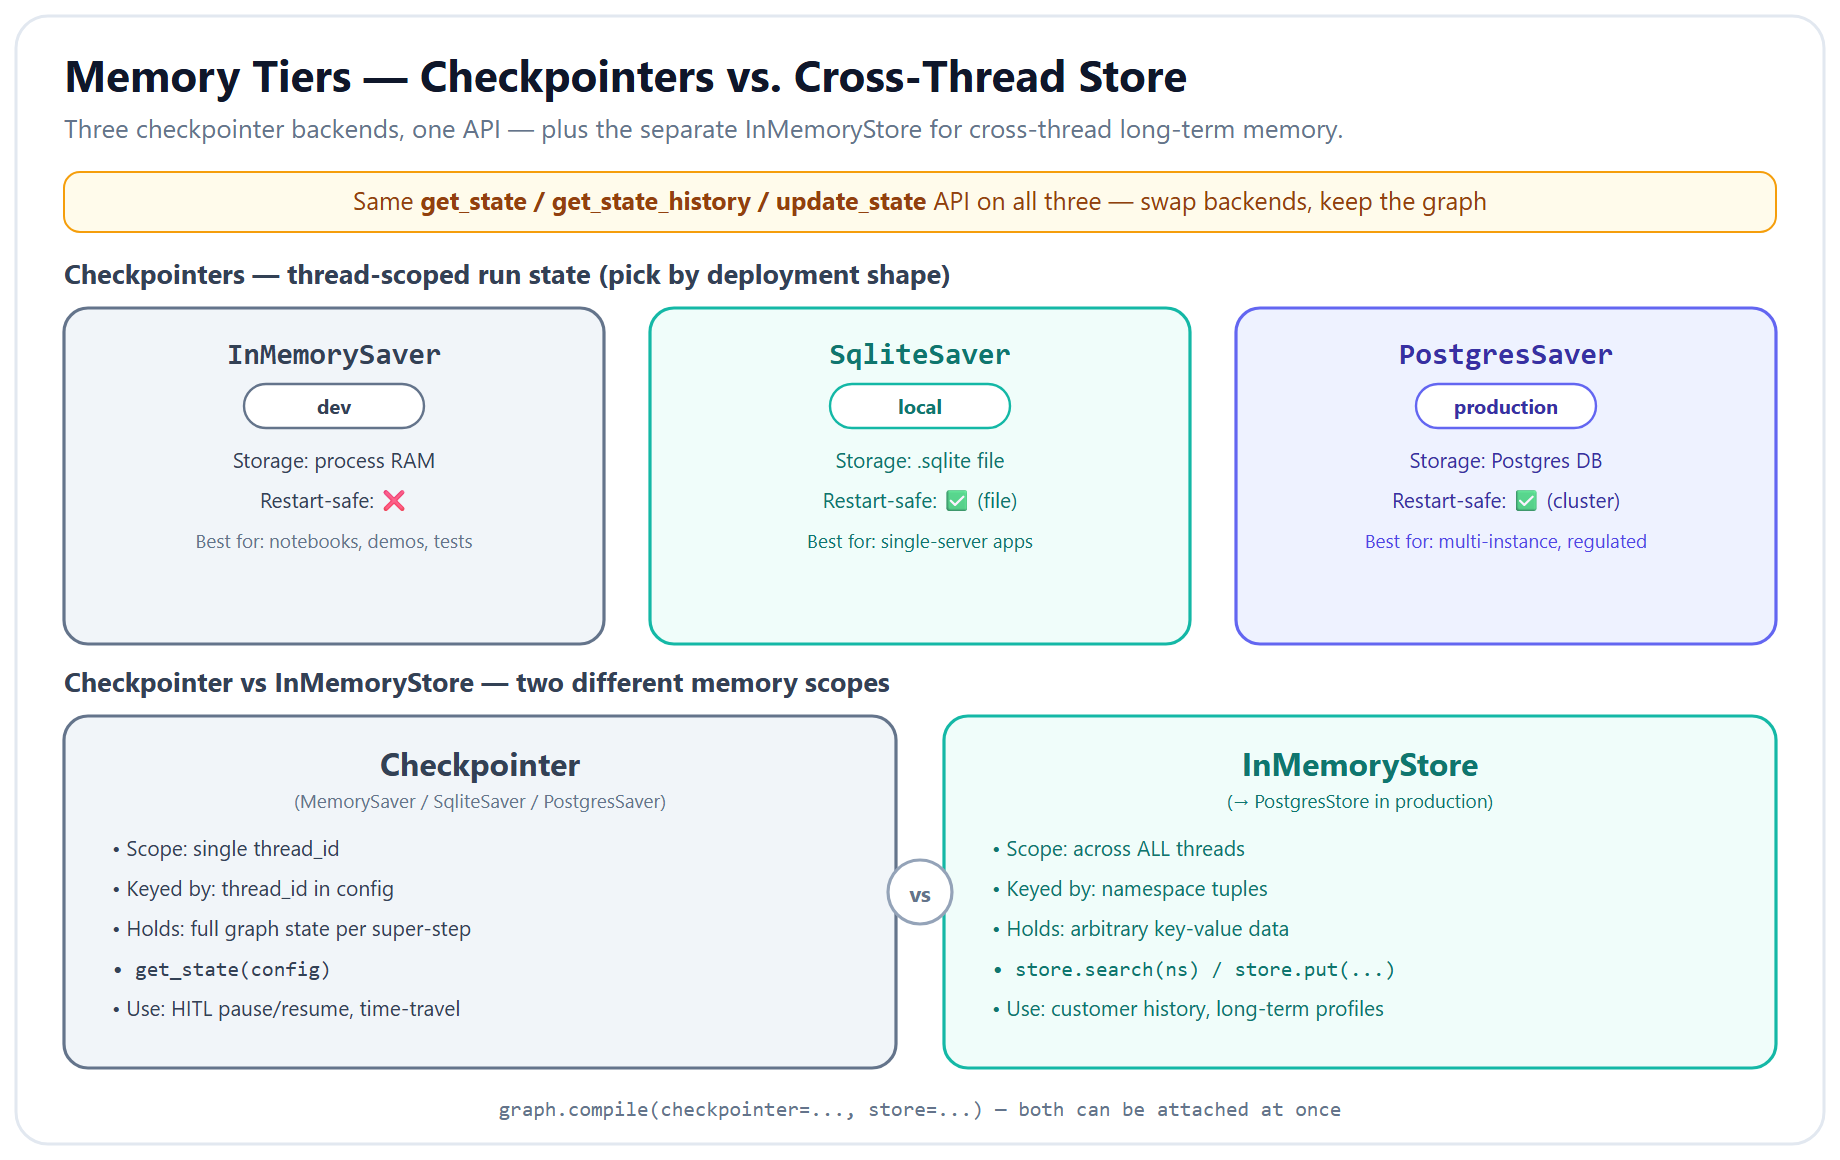

**Figure — Memory tiers.** Three checkpointer backends share one API at increasing durability tiers; a checkpointer holds per-thread run state while `InMemoryStore` holds cross-thread long-term memory.

> ⏭️ **After the session.** This section is not run live in the workshop. Work through it afterwards, top to bottom.

## 22. BONUS: Middleware-Based HITL with `create_agent`

LangChain v1 introduces `HumanInTheLoopMiddleware` as an alternative to manual `interrupt()` calls. This works with `create_agent` (the new agent API) rather than custom `StateGraph` workflows.

| Approach | Best For | API |
|----------|----------|-----|
| `interrupt()` in StateGraph | Custom graph workflows with complex routing | `langgraph.types.interrupt` |
| `HumanInTheLoopMiddleware` | Agent-based workflows with tool-call approval | `langchain.agents.middleware` |

### Key Differences

| Feature | `interrupt()` (StateGraph) | `HumanInTheLoopMiddleware` |
|---------|--------------------------|--------------------------|
| Trigger | You call `interrupt()` anywhere in a node | Middleware auto-intercepts specified tool calls |
| Payload | Custom -- you design the payload | Standardized -- tool name, args, description |
| Decisions | Custom -- you define the format | Three built-in: approve, edit, reject |
| Flexibility | Maximum -- any logic, any condition | Structured -- tool-call focused |
| Complexity | More code, more control | Less code, less flexibility |


In [23]:
# BONUS: HumanInTheLoopMiddleware pattern
# This demonstrates the middleware approach -- runs with create_agent

from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langchain.tools import tool

# Define tools that the agent can call
@tool
def approve_loan(applicant_id: str, amount: float, conditions: str) -> str:
    """Approve a loan application with specified conditions."""
    return f"Loan approved for {applicant_id}: INR {amount:,.0f} with conditions: {conditions}"

@tool
def reject_loan(applicant_id: str, reason: str) -> str:
    """Reject a loan application with a reason."""
    return f"Loan rejected for {applicant_id}: {reason}"

@tool
def check_credit_score(applicant_id: str) -> str:
    """Check the CIBIL credit score for an applicant."""
    score = CREDIT_DATABASE.get(applicant_id, {}).get("credit_score", "Not found")
    return f"CIBIL score for {applicant_id}: {score}"

# Create agent with HITL middleware
# The middleware intercepts approve_loan and reject_loan (high-stakes actions)
# but auto-approves check_credit_score (read-only, safe)
hitl_middleware = HumanInTheLoopMiddleware(
    interrupt_on={
        "approve_loan": {
            "description": "Loan approval requires officer review",
            "allowed_decisions": ["approve", "edit", "reject"],
        },
        "reject_loan": {
            "description": "Loan rejection requires officer review",
            "allowed_decisions": ["approve", "reject"],
        },
        "check_credit_score": False,  # No approval needed (read-only)
    },
    description_prefix="QuickLoan officer review required",
)

checkpointer = InMemorySaver()

loan_agent = create_agent(
    model="gpt-4.1-mini",
    tools=[approve_loan, reject_loan, check_credit_score],
    middleware=[hitl_middleware],
    checkpointer=checkpointer,
    system_prompt=(
        "You are a loan processing agent at QuickLoan. "
        "Check credit scores and make loan decisions. "
        "For any loan decision, use approve_loan or reject_loan tools."
    ),
)

print("Loan agent created with HumanInTheLoopMiddleware")
print("  Tools requiring approval: approve_loan, reject_loan")
print("  Auto-approved tools: check_credit_score")


Loan agent created with HumanInTheLoopMiddleware
  Tools requiring approval: approve_loan, reject_loan
  Auto-approved tools: check_credit_score


In [24]:
# Demo: Invoke the middleware-based HITL agent
from langgraph.types import Command

config_agent = {"configurable": {"thread_id": "agent-001"}}

# Step 1: Ask the agent to process a loan
result = loan_agent.invoke(
    {"messages": [{"role": "user", "content": "Check credit and process loan for CUST-001, amount INR 300000 for home renovation"}]},
    config=config_agent,
    version="v2",
)

# Check if there are interrupts (agent paused for human review)
if hasattr(result, "interrupts") and result.interrupts:
    print("Agent paused for human review!")
    print()
    for intr in result.interrupts:
        print(f"Interrupt payload:")
        print(json.dumps(intr.value, indent=2, default=str))
    print()

    # Resume with approval
    print("Resuming with approval...")
    result = loan_agent.invoke(
        Command(resume={"decisions": [{"type": "approve"}]}),
        config=config_agent,
        version="v2",
    )

# Print final result
if hasattr(result, "value"):
    messages = result.value.get("messages", [])
else:
    messages = result.get("messages", [])

if messages:
    print()
    print("Agent final response:")
    print(messages[-1].content if hasattr(messages[-1], "content") else messages[-1])


Agent paused for human review!

Interrupt payload:
{
  "action_requests": [
    {
      "name": "approve_loan",
      "args": {
        "applicant_id": "CUST-001",
        "amount": 300000,
        "conditions": "Loan approved for home renovation at standard interest rate with a tenure of 5 years."
      },
      "description": "Loan approval requires officer review"
    }
  ],
  "review_configs": [
    {
      "action_name": "approve_loan",
      "allowed_decisions": [
        "approve",
        "edit",
        "reject"
      ]
    }
  ]
}

Resuming with approval...



Agent final response:
The loan for INR 300,000 for home renovation has been approved for CUST-001 at the standard interest rate with a tenure of 5 years. If you need any more assistance, please let me know.


---

## 23. Persistent Checkpointing with `SqliteSaver`

`InMemorySaver` is great for notebooks but loses everything on process exit. For local prototyping or single-server apps, `SqliteSaver` writes checkpoints to a `.sqlite` file — the same graph code, **survives restarts**, and can be inspected with any SQLite browser.

| Checkpointer | Storage | Best for | Restart-safe? |
|---|---|---|---|
| `InMemorySaver` | Process RAM | Notebooks, demos, CI tests | ❌ |
| `SqliteSaver` | `.sqlite` file | Local prototype, single-server apps | ✅ (file) |
| `PostgresSaver` | Postgres DB | Multi-instance prod, regulated workloads | ✅ (cluster) |

> **Production note.** `PostgresSaver` is the production default — it survives restarts and supports multi-instance deployments behind a load balancer. > All three checkpointers expose the same `get_state` / `get_state_history` / `update_state` API, so you can switch backends without changing the graph definition.


In [25]:
# Re-compile the same graph against a SqliteSaver to verify the swap is one-line.
# Note: from langgraph 1.0+ the SQLite checkpointer lives in `langgraph-checkpoint-sqlite`.
from langgraph.checkpoint.sqlite import SqliteSaver

# Use a context manager — opens the connection, ensures schema, closes cleanly.
with SqliteSaver.from_conn_string('quickloan_checkpoints.sqlite') as sqlite_saver:
    sqlite_graph = builder.compile(checkpointer=sqlite_saver)

    # Run a small auto-approve case end-to-end against the file-backed checkpointer.
    sqlite_config = {'configurable': {'thread_id': 'sqlite-demo-001'}}
    # The same input as Test Case 1 (§13): the auto-approve customer, now against the file.
    sqlite_customer = CUSTOMER_DATABASE['CUST-001']
    result = sqlite_graph.invoke({
        'applicant_name':        sqlite_customer['name'],
        'applicant_id':          'CUST-001',
        'loan_amount':           sqlite_customer['loan_amount'],
        'loan_purpose':          sqlite_customer['loan_purpose'],
        'annual_income':         sqlite_customer['annual_income'],
        'employment_type':       sqlite_customer['employment_type'],
        'credit_score':          0,
        'credit_report_summary': '',
        'debt_to_income_ratio':  0.0,
        'ai_recommendation':     '',
        'ai_reasoning':          '',
        'ai_conditions':         [],
        'ai_confidence':         0.0,
        'human_decision':        {},
        'final_decision':        '',
        'final_response':        '',
        'processing_log':        [],
    }, config=sqlite_config)

    print(f'Final response: {result.get("final_response", "<none>")[:140]} ...')
    print()
    print('State checkpoints written to quickloan_checkpoints.sqlite')
    print(f'Number of checkpoints saved for this thread: '
          f'{len(list(sqlite_graph.get_state_history(sqlite_config)))}')

# After exiting the context manager, the SQLite file persists on disk.
# Re-running this cell would resume / append to the same checkpoint history.


Final response: Dear Rajesh Kumar,

We are pleased to inform you that your loan application for INR 300,000 has been approved. To proceed with the disbursal ...

State checkpoints written to quickloan_checkpoints.sqlite
Number of checkpoints saved for this thread: 6


> ⏭️ **After the session.** This section is not run live in the workshop. Work through it afterwards, top to bottom.

---

## 24. Time-Travel Replay — Rewind, Edit, Resume

One of LangGraph's most underrated features: every checkpointer lets you **walk back through state history, edit a past snapshot, and resume from there**. This is the production debugging story — when a loan was rejected and the customer disputes, you can replay the exact decision flow, tweak one input ("what if we'd had the updated credit score?"), and see what the graph would have done differently. No re-running the LLM from scratch on the unchanged steps.

**The 4-step time-travel pattern:**
1. `graph.get_state_history(config)` — list every checkpoint for a thread (newest first).
2. Pick the checkpoint you want to fork from (each has a `checkpoint_id`).
3. `graph.update_state(checkpoint_config, {'field': new_value})` — write a new checkpoint with edited values.
4. `graph.invoke(None, config=new_config)` — resume from the edited checkpoint.


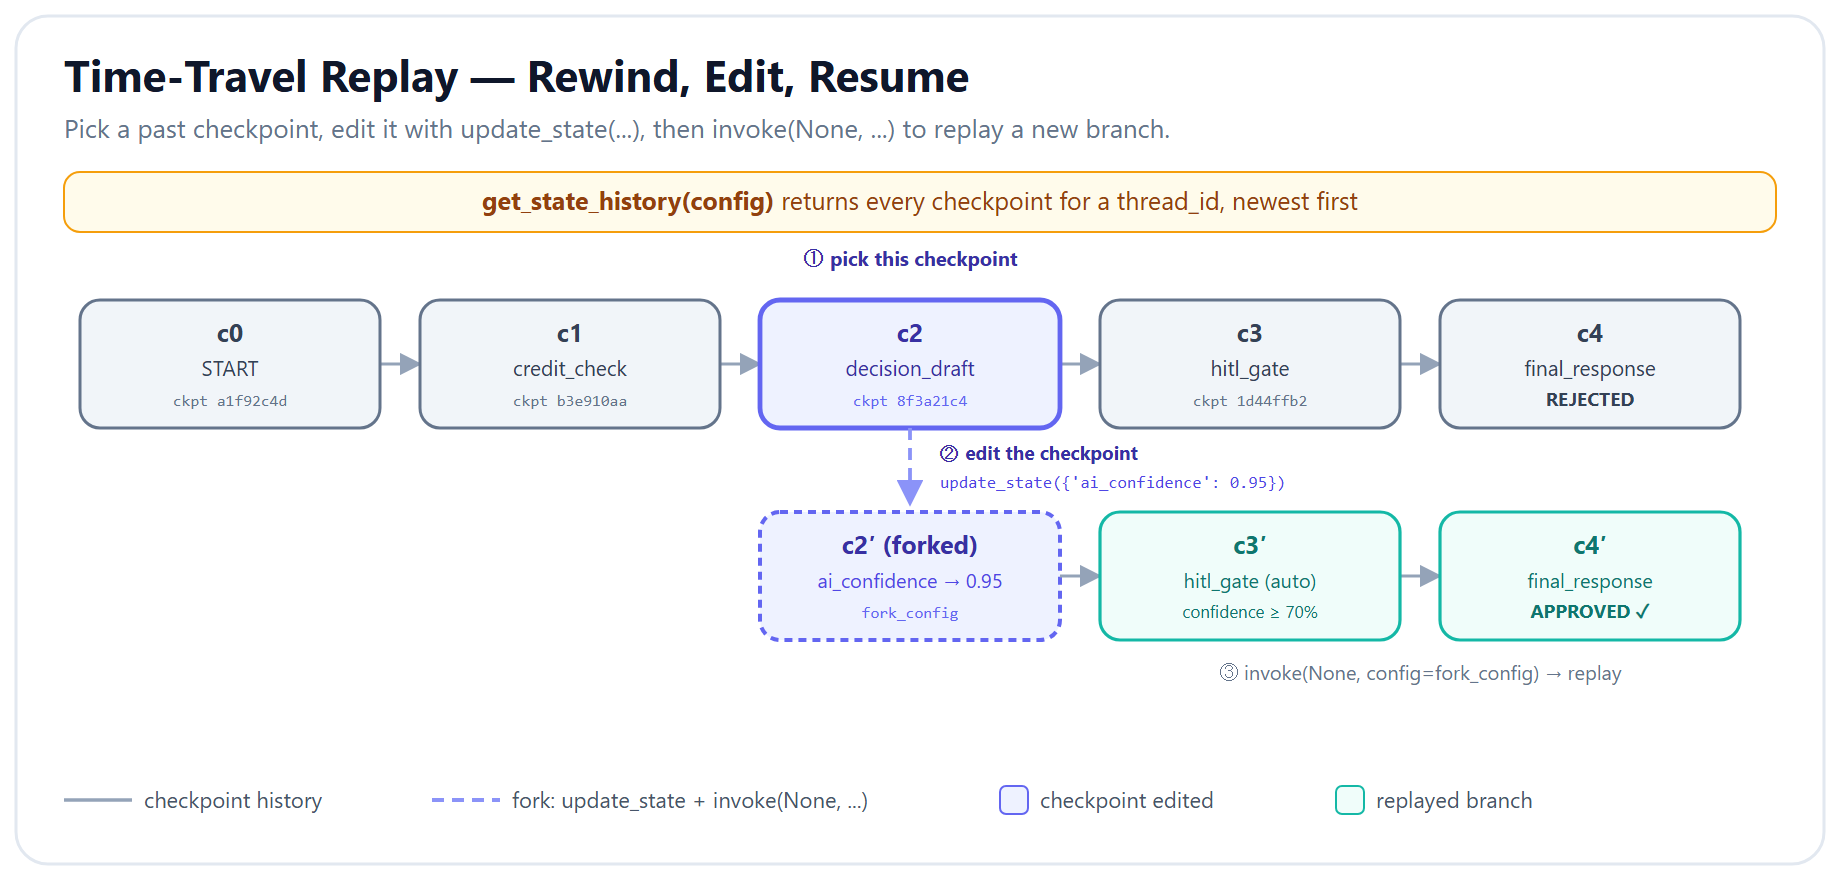

**Figure — Time-travel replay.** Pick a past checkpoint, edit its state with `update_state(...)`, then `invoke(None, config=fork_config)` to replay a new branch — unchanged upstream steps are not re-run.

In [26]:
# Replay a *rejected* large-loan application, change one field, and resume.
# We use Test Case 3's thread (thread_id='loan-003') from earlier in the lab.

from langgraph.types import Command

replay_config = {'configurable': {'thread_id': 'loan-003'}}
history = list(graph.get_state_history(replay_config))
print(f'Total checkpoints for loan-003: {len(history)}')
print()

# Show the tail of the history so we can see which checkpoints we can fork from.
print('Recent checkpoints (newest first):')
for snap in history[:6]:
    step = snap.metadata.get('step', '?')
    checkpoint_source  = snap.metadata.get('source', '?')
    next_nodes  = snap.next
    print(f'  step={step:>3}  source={checkpoint_source:<10}  next={next_nodes}  ckpt={snap.config["configurable"]["checkpoint_id"][:8]}...')


Total checkpoints for loan-003: 6

Recent checkpoints (newest first):
  step=  4  source=loop        next=()  ckpt=1f1bc56b...
  step=  3  source=loop        next=('final_response',)  ckpt=1f1bc56b...
  step=  2  source=loop        next=('hitl_gate',)  ckpt=1f1bc56b...
  step=  1  source=loop        next=('decision_draft',)  ckpt=1f1bc56b...
  step=  0  source=loop        next=('credit_check',)  ckpt=1f1bc56b...
  step= -1  source=input       next=('__start__',)  ckpt=1f1bc56b...


In [27]:
# Pick a checkpoint that was *just before* the HITL gate fired — we'll fork from there
# and pretend the AI's confidence had been higher (so the gate would auto-approve).
fork_snapshot = next(
    (snapshot for snapshot in history if 'decision_draft' in (snapshot.metadata.get('writes') or {})),
    None,
)

if fork_snapshot is None:
    print('No decision_draft checkpoint found in this thread — skipping demo.')
else:
    print('Forking from checkpoint with state:')
    print(f'  decision_draft: {fork_snapshot.values.get("decision_draft", "<none>")[:100]}')
    print(f'  ai_confidence:  {fork_snapshot.values.get("ai_confidence", "<unknown>")}')
    print()

    # Edit the AI confidence to a value that bypasses the HITL gate (e.g., 0.95)
    # and write a new checkpoint at that point in history.
    fork_config = graph.update_state(
        fork_snapshot.config,
        {'ai_confidence': 0.95},
    )
    print('New checkpoint written with ai_confidence=0.95.')
    print(f'Forked config: {fork_config}')
    print()

    # Resume from the forked checkpoint. invoke(None, ...) means "continue from saved state".
    replay_result = graph.invoke(None, config=fork_config)
    print('Replayed result (with edited confidence):')
    print(f'  final_decision : {replay_result.get("final_decision", "<none>")}')
    print(f'  final_response : {replay_result.get("final_response", "<none>")[:160]} ...')


No decision_draft checkpoint found in this thread — skipping demo.


---
## 25. Conclusion & Key Takeaways

### What We Covered

| Concept | Takeaway |
|---|---|
| **`interrupt()` + `Command(resume=...)`** | Pause the graph, hand a payload to a human, resume with their decision as the return value of `interrupt()` |
| **Checkpointer is required for HITL** | Without a checkpointer, the graph has no way to remember where it paused — `interrupt()` would be useless |
| **InMemory → Sqlite → Postgres** | Same API, three persistence tiers — pick by deployment shape (notebook → single-server → cluster) |
| **Thread vs cross-session memory** | Checkpointer = within a thread (this conversation). Store = across threads (same customer over time) |
| **Time-travel replay** | `get_state_history` + `update_state` lets you fork from any past snapshot — debugging gold for production agents |
| **Multi-tier HITL triggers** | Loan amount + credit score + AI confidence — one gate, three signals; tune the threshold per business risk |
| **`HumanInTheLoopMiddleware`** | The agent-flavoured cousin: approve / edit / reject individual tool calls without writing graph topology |

**Next Lab:** Lab 7.3 — Parallelization: Fan-Out / Fan-In with the Send API ⚡


> ⏭️ **After the session.** This section is not run live in the workshop. Work through it afterwards, top to bottom.

## 26. Stretch Exercise (Optional)

1. Implement a **multi-level approval flow**: loans > ₹25 lakh need *both* a manager and a VP to approve before resuming. (Hint: two `interrupt()` calls, one after the other.)
2. Replace `InMemoryStore` cross-session memory with a **vector-backed `Store`** that does semantic similarity search across past loan decisions for the same customer.
3. Build a **dashboard cell** that takes a `thread_id` and prints every checkpoint (step, node, ai_confidence, decision) — the audit-trail view a compliance officer wants.
4. Wire `PostgresSaver` (instead of SqliteSaver) and verify the same time-travel replay works against a Postgres backend. (Requires a local Postgres or a Neon free instance.)
5. Add a **timeout-safe HITL pattern**: if the human doesn't respond within 24 hours, auto-route the application to a `defer` node that emails the customer.
